In [104]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
import pandas as pd; pd.set_option("display.max_columns", None)
import sys;sys.path.append("..")
from config import Paths
from dataframes import *
from eals_data.utils import venn_diagram
from eals_radcliff.utils import dataframes as radcliff_dataframes
from eals_radcliff.utils import dataframes_paper as radcliff_dataframes_paper

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
from eals_radcliff.models.LMM import model as lmm_model

# ALSFRS-R

In [107]:
feature='ALS_total'
XLIM = (-.1, 2)
YLIM = (0, 1.7)

### RAPA

In [108]:
df_als = load_alsfrsr_data()
df_als[f'{feature}_zscore'] = (df_als[feature] - df_als[feature].mean()) / df_als[feature].std()
print(f'N pALS: {df_als.user_id.nunique()}, N sessions: {df_als.session_id.nunique()}')
df_als.head(2)

N pALS: 17, N sessions: 140


,speech,salvation,swallowing,handwriting,cutting_food_a,cutting_food_b,dressing_and_hygiene,turning_in_bed,walking,climbing_stairs,dyspnea,orthopnea,respiratory_insufficiency,ALS_total,created_at,user_id,date,bulbar_subscore,respiratory_subscore,fine_motor_subscore,gross_motor_subscore,session_id,months_since_first_session,years_since_first_session,ALS_total_zscore
0,4,4,4,3,3.0,NaN,3,3,3,1,4,3,4,39,2024-05-24 15:45:27+00:00,a07848cb-83b1-48ef-a314-ae5b5e5d448b,2024-05-24,12,11,NaN,7,a07848cb-83b1-48ef-a314-ae5b5e5d448b__2024-05-24,0.0,0.0,1.334330
1,4,4,4,3,2.0,4.0,2,3,2,1,4,0,2,31,2024-05-24 18:31:52+00:00,cee20458-8561-4496-932c-6855e6299641,2024-05-24,12,6,11.0,6,cee20458-8561-4496-932c-6855e6299641__2024-05-24,0.0,0.0,0.403209


ALS_total ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         ALS_total
No. Observations:          140             Method:                     REML     
No. Groups:                17              Scale:                      4.7194   
Min. group size:           1               Log-Likelihood:             -341.5932
Max. group size:           30              Converged:                  Yes      
Mean group size:           8.2                                                  
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             24.433    2.108 11.591 0.000 20.302 28.565
years_since_first_session             -1.624                   

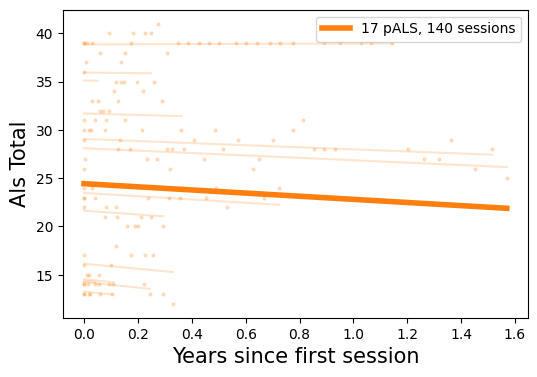

Population	Intercept (SE)	Slope (SE) (1/Years)
17 pALS, 140 sessions	24.433 (2.108)	-1.624 (nan)


In [109]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()}"
result_dict = lmm_model.run_lmm_analysis(
    df_als,#.query('ALS_total>0'),
    dependant_variable= feature,
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

ALS_total_zscore ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       ALS_total_zscore
No. Observations:       140           Method:                   REML            
No. Groups:             17            Scale:                    0.0639          
Min. group size:        1             Log-Likelihood:           -44.7818        
Max. group size:        30            Converged:                Yes             
Mean group size:        8.2                                                     
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.361    0.245 -1.472 0.141 -0.842  0.120
years_since_first_session             -0.189            

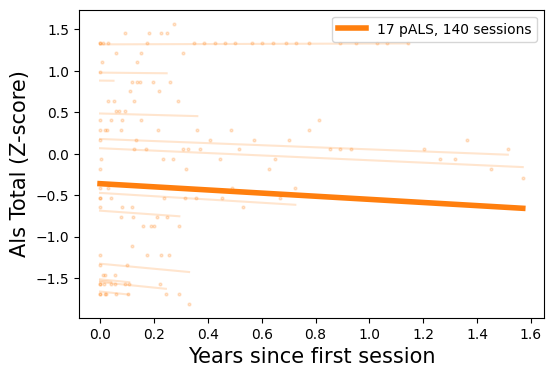

Population	Intercept (SE)	Slope (SE) (1/Years)
17 pALS, 140 sessions	-0.361 (0.245)	-0.189 (nan)


In [69]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()} (Z-score)"
result_dict = lmm_model.run_lmm_analysis(
    df_als,
    dependant_variable= f'{feature}_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

### Radcliff

In [70]:
df_als_radcliff = radcliff_dataframes.load_alsfrsr_data()

# Compute months since the first session per user (vectorized)
first_date = df_als_radcliff.groupby('user_id')['date'].transform('min')
months = (df_als_radcliff['date'] - first_date) / np.timedelta64(30, 'D')  # ~months as float
df_als_radcliff.loc[:, 'months_since_first_session'] = months
df_als_radcliff.loc[:, 'years_since_first_session'] = df_als_radcliff['months_since_first_session'] / 12.0

ALS_total ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         ALS_total 
No. Observations:         1298            Method:                     REML      
No. Groups:               70              Scale:                      2.6759    
Min. group size:          1               Log-Likelihood:             -2698.8980
Max. group size:          99              Converged:                  Yes       
Mean group size:          18.5                                                  
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             40.839    0.676 60.444 0.000 39.515 42.163
years_since_first_session             -5.221    0.885 -5.899 0.

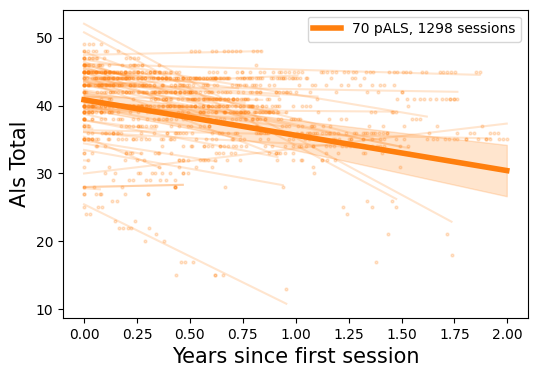

Population	Intercept (SE)	Slope (SE) (1/Years)
70 pALS, 1298 sessions	40.839 (0.676)	-5.221 (0.885)


In [71]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()}"
result_dict = lmm_model.run_lmm_analysis(
    df_als_radcliff,
    dependant_variable= feature,
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

### Both

In [24]:
df1 = df_als_radcliff[['user_id', 'years_since_first_session', 'date', 'session_id', feature]]
df1['is_radcliff'] = True
df2 = df_als[['user_id', 'years_since_first_session', 'date', 'session_id', feature]]
df2['is_radcliff'] = False
df_fix = pd.concat([df1, df2], ignore_index=True)

In [25]:
label_false = 'RAPA'
label_true = 'Radcliff' 
grouping_variable = 'is_radcliff'

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()}"
result_dict = lmm_model.run_lmm_analysis(
    df_fix,
    dependant_variable= feature,
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    label_true= label_true,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

TypeError: 'values' is not ordered, please explicitly specify the categories order by passing in a categories argument.

# ROADS

In [72]:
df_roads = load_roads_data()
df_roads['total_zscore'] = (df_roads['total'] - df_roads['total'].mean()) / df_roads['total'].std()
# Compute months since the first session per user (vectorized)
first_date = df_roads.groupby('user_id')['date'].transform('min')
months = (df_roads['date'] - first_date) / np.timedelta64(30, 'D')  # ~months as float
df_roads.loc[:, 'months_since_first_session'] = months
df_roads.loc[:, 'years_since_first_session'] = df_roads['months_since_first_session'] / 12.0

total ~ years_since_first_session
1 + years_since_first_session
                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         total    
No. Observations:           142             Method:                     REML     
No. Groups:                 17              Scale:                      8.9380   
Min. group size:            1               Log-Likelihood:             -393.5674
Max. group size:            30              Converged:                  Yes      
Mean group size:            8.4                                                  
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                              23.565    2.742  8.594 0.000 18.191 28.939
years_since_first_session              -2.257    2.949 -

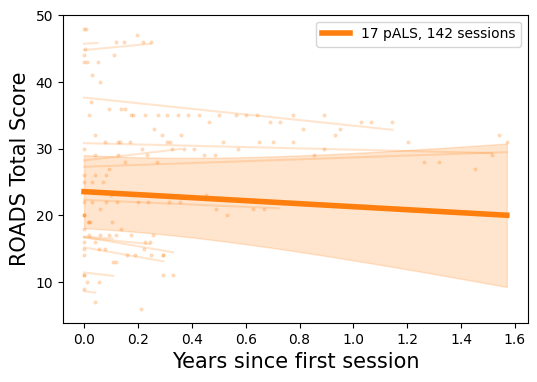

Population	Intercept (SE)	Slope (SE) (1/Years)
17 pALS, 142 sessions	23.565 (2.742)	-2.257 (2.949)


In [110]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = "ROADS Total Score"
result_dict = lmm_model.run_lmm_analysis(
    df_roads.query('total<55'),
    dependant_variable= 'total',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

total_zscore ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        total_zscore
No. Observations:         142            Method:                    REML        
No. Groups:               17             Scale:                     0.0871      
Min. group size:          1              Log-Likelihood:            -69.4122    
Max. group size:          30             Converged:                 Yes         
Mean group size:          8.4                                                   
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.370    0.271 -1.365 0.172 -0.900  0.161
years_since_first_session             -0.223    0.291 -0.766

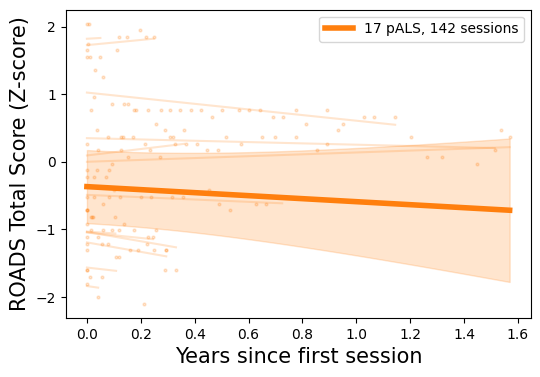

Population	Intercept (SE)	Slope (SE) (1/Years)
17 pALS, 142 sessions	-0.370 (0.271)	-0.223 (0.291)


In [93]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = "ROADS Total Score (Z-score)"
result_dict = lmm_model.run_lmm_analysis(
    df_roads.query('total<55'), #weird outlier
    dependant_variable= 'total_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()